# Task 56 – Neural Network from Scratch
**Reference:** https://www.analyticsvidhya.com/blog/2020/07/neural-networks-from-scratch-in-python-and-r

Solving the XOR problem with a 2-layer neural network built entirely with NumPy.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# XOR dataset
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

In [2]:
np.random.seed(42)
lr = 0.1; epochs = 10000
W1 = np.random.randn(2,4); b1 = np.zeros((1,4))
W2 = np.random.randn(4,1); b2 = np.zeros((1,1))

def sigmoid(z): return 1/(1+np.exp(-z))
def sigmoid_d(z): s=sigmoid(z); return s*(1-s)

In [3]:
losses = []
for _ in range(epochs):
    Z1=X.dot(W1)+b1; A1=sigmoid(Z1)
    Z2=A1.dot(W2)+b2; A2=sigmoid(Z2)
    loss=np.mean((y-A2)**2); losses.append(loss)
    dZ2=-(y-A2)*sigmoid_d(Z2)
    dW2=A1.T.dot(dZ2); db2=np.sum(dZ2,axis=0,keepdims=True)
    dZ1=dZ2.dot(W2.T)*sigmoid_d(Z1)
    dW1=X.T.dot(dZ1); db1=np.sum(dZ1,axis=0,keepdims=True)
    W2-=lr*dW2; b2-=lr*db2; W1-=lr*dW1; b1-=lr*db1
print('Final Loss:', losses[-1])

Final Loss: 0.002788157071692764


In [4]:
for i in range(len(X)):
    print(f'Input:{X[i]}  Predicted:{A2[i][0]:.4f}  Actual:{y[i][0]}')

Input:[0 0]  Predicted:0.0373  Actual:0
Input:[0 1]  Predicted:0.9491  Actual:1
Input:[1 0]  Predicted:0.9448  Actual:1
Input:[1 1]  Predicted:0.0643  Actual:0


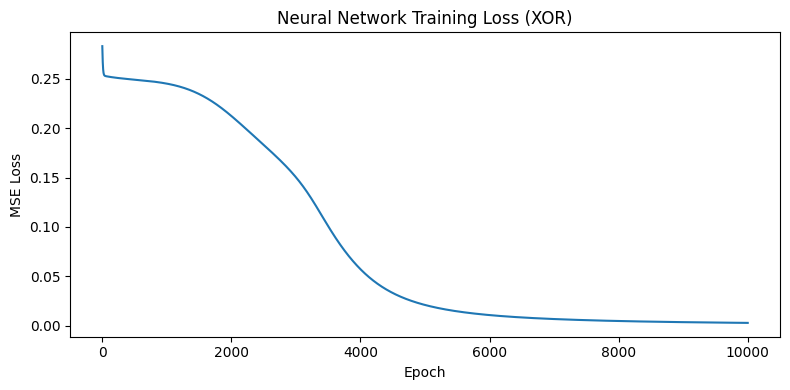

In [5]:
plt.figure(figsize=(8,4))
plt.plot(losses)
plt.title('Neural Network Training Loss (XOR)')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.tight_layout(); plt.show()